In [1]:
import sys
sys.path.append('../utils/')
from utils_models import *
from utils_jax import modified_drag_pulse

In [5]:
EJ = 4
EC = 4/5.9
EL = 4/29.2

n_lvls_transmon  = 4
n_lvls_fluxonium = 20

transmon_EJ,g,amp =  [3.56153334e+01, 9.91957369e-02, 2.73280218e-02]

fluxonium = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=n_lvls_fluxonium)
transmon = scqubits.Transmon(
    EJ=transmon_EJ,
    EC=0.2,
    ng=0.0,
    ncut=10,
    truncated_dim = 4
    )

system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '0,2',
    g_strength = g,
    )

e_ops = []
for ql in range(n_lvls_fluxonium):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))


# Now I need to calculate the DRAG pulse integrated area to fix DRAG parameteres
# For gaussian, amp * sigma * sqrt(2) = area.

sigma = amp * 108.75  / amp /np.sqrt(2) * 1.15
pulse_length = 6*sigma
beta = 0
tlist = np.linspace(0,pulse_length,4* int(pulse_length))

     
results = system.run_qutip_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i,0)])) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=modified_drag_pulse,
                pulse_shape_args={
                            'w_d': system.evals[system.product_to_dressed[(1,1)]] - system.evals[system.product_to_dressed[(1,0)]],
                            'amp': amp/(2*np.pi),
                            'duration': pulse_length,
                            'sigma': sigma,
                            'beta':beta
                        } ,
                )],
        c_ops = None,
        e_ops = e_ops
    )


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


 Total run time:  42.55s*] Elapsed 42.55s / Remaining 00:00:00:00 [*********97%********** ] Elapsed 41.50s / Remaining 00:00:00:01
 [*********99%***********] Elapsed 42.53s / Remaining 00:00:00:00

Processing states with pad_back_custom:   0%|          | 0/2120 [00:00<?, ?it/s]7371.27it/s]

 Total run time:  42.71s*] Elapsed 42.71s / Remaining 00:00:00:00
 [********100%***********] Elapsed 43.01s / Remaining 00:00:00:00

Processing states with pad_back_custom:  69%|██████▉   | 1467/2120 [00:00<00:00, 7414.42it/s]

 [********100%***********] Elapsed 43.16s / Remaining 00:00:00:00

Processing states with pad_back_custom:   0%|          | 0/2120 [00:00<?, ?it/s]

 Total run time:  43.24s*] Elapsed 43.24s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 2120/2120 [00:00<00:00, 5633.00it/s]


(424.4762007462844, 530.5952509328555)

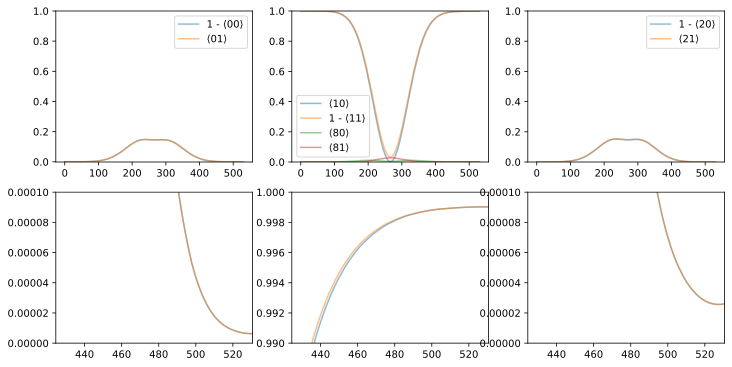

In [8]:
# Sigma correction : 1.15

colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1)],
                        [(1,0),(1,1),(8,0),(8,1)],
                        [(2,0),(2,1)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,0), (1,1),(2,0)]:
                axes[row, col].plot(tlist,results[col].expect[i],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
            else:
                axes[row, col].plot(tlist,1 - results[col].expect[i],label = rf"1 - $\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    # axes[1,col].set_xlim(260,280)
axes[0,0].set_ylim(-1e-3,1)
axes[0,1].set_ylim(-1e-5,1)
axes[0,2].set_ylim(-1e-5,1)
axes[1,0].set_ylim(0,1e-4)
axes[1,1].set_ylim(1-1e-2,1)
axes[1,2].set_ylim(0,1e-4)

xa = pulse_length - pulse_length*0.2
xb = pulse_length
axes[1,0].set_xlim(xa,xb)
axes[1,1].set_xlim(xa,xb)
axes[1,2].set_xlim(xa,xb)

(413.4029085529031, 516.7536356911289)

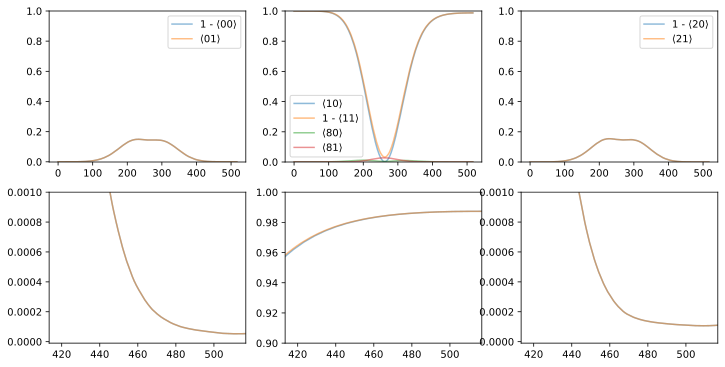

In [4]:
# Sigma correction : 1.12

colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1)],
                        [(1,0),(1,1),(8,0),(8,1)],
                        [(2,0),(2,1)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,0), (1,1),(2,0)]:
                axes[row, col].plot(tlist,results[col].expect[i],label = rf"$\langle{ql}{tl}\rangle$",alpha=0.5)
            else:
                axes[row, col].plot(tlist,1 - results[col].expect[i],label = rf"1 - $\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    # axes[1,col].set_xlim(260,280)
axes[0,0].set_ylim(-1e-3,1)
axes[0,1].set_ylim(-1e-5,1)
axes[0,2].set_ylim(-1e-5,1)
axes[1,0].set_ylim(-1e-5,1e-3)
axes[1,1].set_ylim(1-1e-1,1)
axes[1,2].set_ylim(-1e-5,1e-3)

xa = pulse_length - pulse_length*0.2
xb = pulse_length
axes[1,0].set_xlim(xa,xb)
axes[1,1].set_xlim(xa,xb)
axes[1,2].set_xlim(xa,xb)